In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import nltk
from nltk.corpus import stopwords

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("review_data.csv", sep=None, engine="python")

print(df.head())
print(df.info())

                                    title  rating  \
0                       Perfectly matched       5   
1                              Foundation       5   
2      Excellent helpful customer service       5   
3  How did I survive without this awesome       5   
4                       Perfect thank you       5   

                                              review  
0             Perfectly matched , luxurious coverage  
1  Thorough quiz to ensure the customer receives ...  
2       Excellent helpful customer service Thank you  
3  How did I survive without this awesome make up...  
4                                  Perfect thank you  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   515 non-null    object
 1   rating  515 non-null    int64 
 2   review  515 non-null    object
dtypes: int64(1), object(2)
memory usage: 12.2+ KB
None


In [4]:
# convert text to lowercase
df["review"] = df["review"].str.lower()

In [5]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thano\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [7]:
df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,"perfectly matched , luxurious coverage",perfectly matched luxurious coverage
1,thorough quiz to ensure the customer receives ...,thorough quiz ensure customer receives best pr...
2,excellent helpful customer service thank you,excellent helpful customer service thank
3,how did i survive without this awesome make up...,survive without awesome make upperfect perfect...
4,perfect thank you,perfect thank


In [8]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(df["clean_review"])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (515, 950)


In [13]:
# Create sentiment labels from rating

df["sentiment"] = df["rating"].apply(lambda x: 1 if x >= 3 else 0)

y = df["sentiment"]

print(df["sentiment"].value_counts())

sentiment
1    395
0    120
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=2,
    solver="liblinear"
)

log_model.fit(X_train, y_train)

LogisticRegression(C=2, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

In [21]:
log_pred = log_model.predict(X_test)

In [22]:
print("Logistic Regression Results\n")

accuracy = accuracy_score(y_test, log_pred)
precision = precision_score(y_test, log_pred)
recall = recall_score(y_test, log_pred)
f1 = f1_score(y_test, log_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Logistic Regression Results

Accuracy: 0.9029
Precision: 0.9259
Recall: 0.9494
F1-score: 0.9375


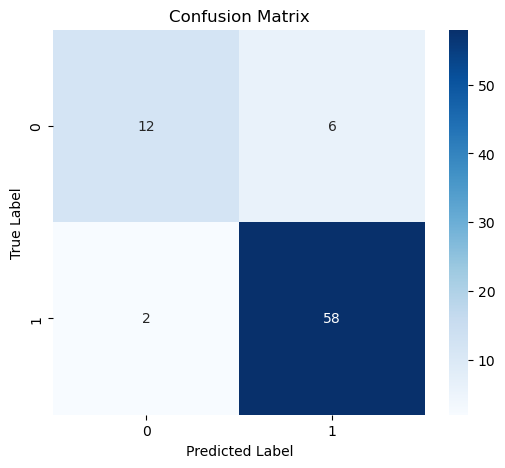

In [18]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()